In [2]:
"""
Cleaned up version of the integration imports we need to actually run this code together.
"""

import numpy as np
from scipy import signal
from optic.models.devices import mzm, photodiode, edfa, iqm, coherentReceiver, pdmCoherentReceiver, basicLaserModel
from optic.models.channels import linearFiberChannel, ssfm
from optic.comm.modulation import modulateGray, grayMapping
from optic.comm.sources import bitSource, symbolSource
from optic.dsp.core import upsample, pulseShape, pnorm, anorm, signalPower, firFilter, decimate, symbolSync,phaseNoise

try:
    from optic.dsp.coreGPU import checkGPU
    if checkGPU():
        from optic.dsp.coreGPU import firFilter
    else:
        from optic.dsp.core import firFilter
except ImportError:
    from optic.dsp.core import firFilter

from optic.utils import parameters, dBm2W, ber2Qfactor
from optic.plot import eyediagram, pconst, plotPSD
import matplotlib.pyplot as plt
from scipy.special import erfc
from tqdm.notebook import tqdm
import scipy as sp
import scipy.constants as const

try:
    from optic.models.modelsGPU import manakovSSF
except:
    from optic.models.channels import manakovSSF

from optic.dsp.equalization import edc, mimoAdaptEqualizer, ffe
from optic.dsp.carrierRecovery import cpr, fourthPowerFOE
from optic.comm.metrics import fastBERcalc, monteCarloGMI, monteCarloMI, calcEVM, bert
from optic.dsp.clockRecovery import gardnerClockRecovery


import logging as logg
logg.basicConfig(level=logg.INFO, format='%(message)s', force=True)
import time

In [3]:
# --------------------------------------------------------------------------------------------------------------------------------------
# Parameters Configuration of Optical System
# ---------------------------------------------------------------------------------------------------------------------------------------


# -----------------------------------------------
# Transmitter Parameters
#-------------------------------------------------

# 1) General Parameters
SpS = 16                 # samples per symbol
Rs = 32e9                # symbol rate [baud]
Fs = Rs * SpS            # sampling frequency [Hz]
M = 16                   # QPSK -> M=4, constType='qam'
nBits = 400000           # total bits to generate
rollOff = 0.01           # RRC roll-off
nFilterTaps = 1024       # RRC filter taps
mzmScale = 0.5           # IQM drive scale = "modulation depth" (0.5 is default in OptiCommPy)
Vpi = 2                  # IQM pi Voltage  (2V is defualt in OpticommPy)
P_launch_dBm = 0         # desired launched optical power [dBm] -- for 4QAM try 6 dbm -- for 16QAM 0 was good
laserLinewidth = 0   # Hz (set e.g. 100e3 for phase noise), setting laserLineWidth to 0, models the ideal case 

# 2) Symbol Source Parameters
paramSymb = parameters()
paramSymb.nSymbols = int(nBits // np.log2(M))  # symbols = bits / log2(M)
paramSymb.M = M
paramSymb.constType = "qam"                    # 'qam' with M=4 -> QPSK
paramSymb.dist = "uniform"                     # uniform symbol probabilities
paramSymb.seed = 444
paramSymb.shapingFactor = 0

constSymb = grayMapping(paramSymb.M, paramSymb.constType)
if paramSymb.dist == "uniform":
   px = np.ones(paramSymb.M) / paramSymb.M
elif paramSymb.probDist == "maxwell-boltzmann":
   px = np.exp(-paramSymb.shapingFactor * np.abs(constSymb) ** 2)
   px = px / np.sum(px)
else:
   raise ValueError("Invalid probability distribution.")
paramSymb.px = px

# 3) UpSampling and FIR Parameters
paramPulse = parameters()
paramPulse.pulseType = "rrc"
paramPulse.nFilterTaps = nFilterTaps
paramPulse.rollOff = rollOff
paramPulse.SpS = SpS

# 4) IQM Parameters
paramIQM = parameters()
paramIQM.Vpi = Vpi
paramIQM.VbI = -Vpi
paramIQM.VbQ = -Vpi
paramIQM.Vphi = Vpi/2


# -----------------------------------------------
# Receiver Parameters
#------------------------------------------------

# 1) Local oscillator (LO) parameters:
FO  = -128e6                 # frequency offset
paramLO = parameters()
paramLO.P =2              # power in dBm
paramLO.lw = 0          # laser linewidth
paramLO.RIN_var = 0
paramLO.Fs = Fs
paramLO.seed = 789 # random seed for noise generation
paramLO.freqShift = 0 + FO

# 2) Photodiodes parameters
paramPD = parameters()
paramPD.B = Rs
paramPD.Fs = Fs
paramPD.ideal = True
paramPD.seed = 1011
paramPD.R = 1
paramPD.shotNoise = False
paramPD.thermalNoise = False
paramPD.currentSaturation = False
paramPD.bandwidthLimitation = False

# 3) Frontend parameters
paramFE = parameters()
paramFE.Fs = Fs
paramFE.phaseImb = 0
paramFE.ampImb = 0
paramFE.timeSkew = 0



In [4]:
def simulate_phase_noise():

    # Tx 
    symbTx = symbolSource(paramSymb)      
    
    pulse = pulseShape(paramPulse)
    symbolsUp = upsample(symbTx, SpS)
    sigTx = firFilter(pulse, symbolsUp)

    sigTx = sigTx / np.max(np.abs(sigTx))

    # Keep the Tx laser ideal
    sigLO_tx = np.ones_like(sigTx)

    # Iqm
    sigTxo = iqm(sigLO_tx, mzmScale * sigTx, paramIQM)

    # -------------------------
    # 5) Set launched optical power
    # -------------------------
    # pnorm() normalizes the optical field so that mean(|E|^2)=1.
    # Then multiplying by sqrt(P) sets mean optical power to P (watts).
    # P_launch_W = dBm2W(P_launch_dBm)
    # sigTxo = np.sqrt(P_launch_W) * pnorm(sigTxo)
    # Does not affect phase noise behaviour, can be kept in or removed

    # No Channel
    sigCh = sigTxo

    # Rx LO with phase noise
    paramLO.Ns = len(sigCh)

    sigLO_Rx = basicLaserModel(paramLO)

    # Coherent receiver
    sigRx = coherentReceiver(sigCh, sigLO_Rx, paramFE, paramPD)

    return sigRx

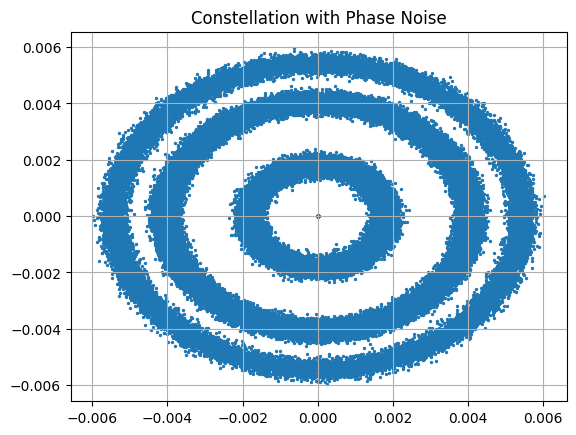

In [5]:
# Constellation Plot

sigRx = simulate_phase_noise()

plt.scatter(sigRx.real[::SpS], sigRx.imag[::SpS], s=2)
#plt.scatter(sigRx.real[:200], sigRx.imag[:200])
plt.title("Constellation with Phase Noise")
plt.grid()

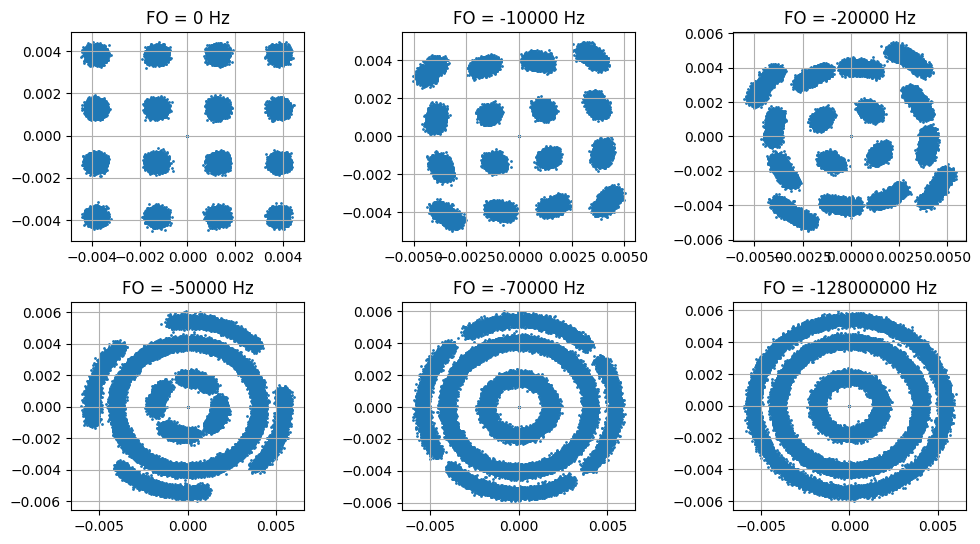

In [9]:
FO_values = [0, -10e3,-20e3,-50e3, -70e3, -128e6]

plt.figure(figsize=(10, 8))

for i, FO in enumerate(FO_values):
    paramLO.freqShift = FO
    paramLO.lw = 0  # IMPORTANT: disable phase noise

    sigRx = simulate_phase_noise()

    plt.subplot(3, 3, i+1)  # 3 rows x 3 columns = 9 plots
    plt.scatter(sigRx.real[::SpS], sigRx.imag[::SpS], s=1)

    plt.title(f"FO = {FO:.0f} Hz")
    plt.grid()

plt.tight_layout()

Text(0.5, 1.0, 'Phase vs Time')

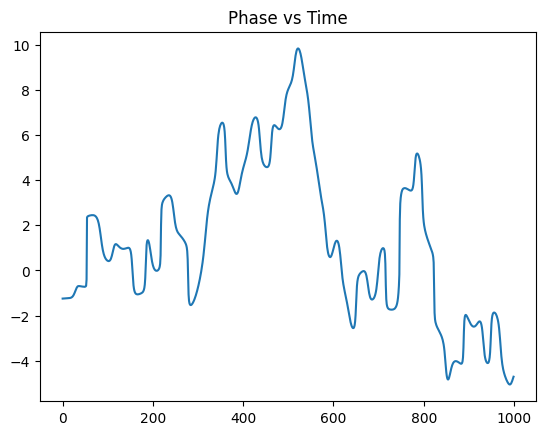

In [10]:
phase = np.unwrap(np.angle(sigRx))

plt.plot(phase[:1000])
plt.title("Phase vs Time")

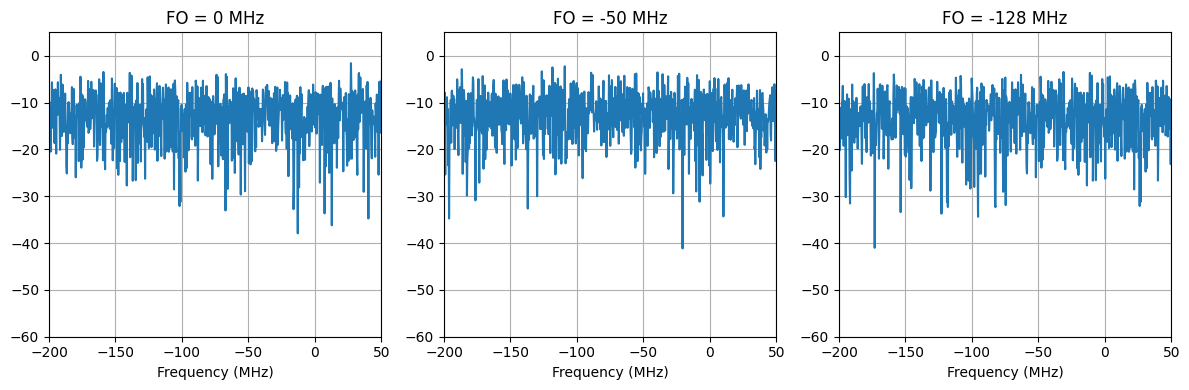

In [11]:
FO_values = [0, -50e6, -128e6]
plt.figure(figsize=(12, 4))

for i, FO in enumerate(FO_values):
    paramLO.freqShift = FO
    paramLO.lw = 0

    sigRx = simulate_phase_noise()

    S = np.fft.fftshift(np.fft.fft(sigRx))
    f = np.fft.fftshift(np.fft.fftfreq(len(S), d=1/Fs))

    power = 20*np.log10(np.abs(S))
    power -= np.max(power)

    plt.subplot(1, 3, i+1)
    plt.plot(f/1e6, power)

    plt.title(f"FO = {FO/1e6:.0f} MHz")
    plt.xlabel("Frequency (MHz)")
    plt.grid()

    # 🔥 Zoomed view
    plt.xlim(-200, 50)
    plt.ylim(-60, 5)

plt.tight_layout()

/tmp/ipykernel_122310/3582533945.py:23: RuntimeWarning: invalid value encountered in divide
  sigNorm = np.where(absRx > 0, sigRx_ds / absRx, 0+0j)


=== FO = -1.2800e+08 Hz ===
Expected 4*FO    : -5.1200e+08 Hz
Detected tone at : -5.1200e+08 Hz
Power at tone    : 0.00 dB
Estimated FO     : -1.2800e+08 Hz
Estimation error : 0.0000e+00 Hz


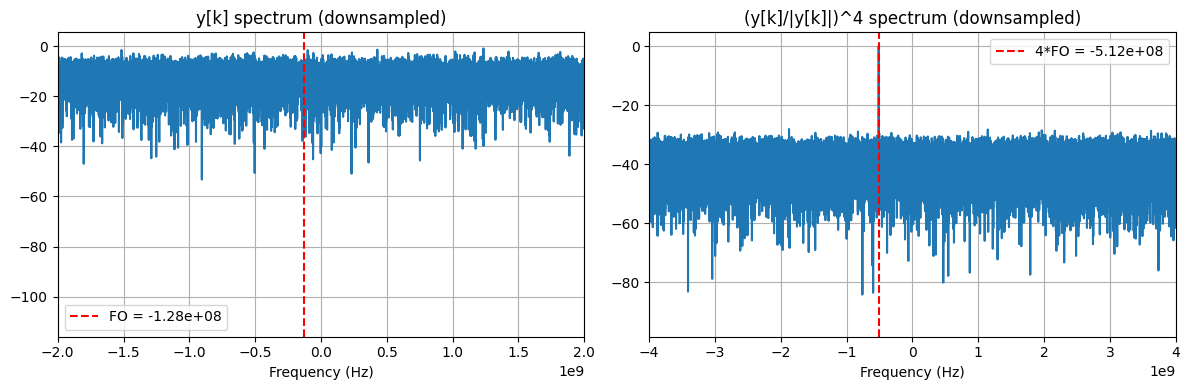

In [16]:
FO_values = [-128e6]
plt.figure(figsize=(12, 4))

for i, FO in enumerate(FO_values):
    paramLO.freqShift = -FO
    paramLO.lw = 0
    sigRx = simulate_phase_noise()

    # Downsample to 2 samples/symbol to bring FO tone away from DC
    sigRx_ds = sigRx[::SpS//2]
    Fs_ds = Fs / (SpS//2)

    # Frequency axis at downsampled rate
    f = np.fft.fftshift(np.fft.fftfreq(len(sigRx_ds), d=1/Fs_ds))

    # -------- (a) Original --------
    S = np.fft.fftshift(np.fft.fft(sigRx_ds))
    power = 20*np.log10(np.abs(S))
    power -= np.max(power)

    # -------- (b) Normalise amplitude FIRST, then 4th power --------
    absRx = np.abs(sigRx_ds)
    sigNorm = np.where(absRx > 0, sigRx_ds / absRx, 0+0j)
    sig4 = sigNorm**4

    S4 = np.fft.fftshift(np.fft.fft(sig4))
    power4 = 20*np.log10(np.abs(S4) + 1e-12)
    power4 -= np.nanmax(power4)

    # -------- Find 4f tone --------
    expected = 4 * FO
    tolerance = 50e6  # ±50 MHz

    mask = (f >= expected - tolerance) & (f <= expected + tolerance)
    peak_idx = np.argmax(np.abs(S4[mask]))
    peak_freq = f[mask][peak_idx]
    peak_power = power4[mask][peak_idx]
    estimated_FO = peak_freq / 4

    print(f"=== FO = {FO:.4e} Hz ===")
    print(f"Expected 4*FO    : {expected:.4e} Hz")
    print(f"Detected tone at : {peak_freq:.4e} Hz")
    print(f"Power at tone    : {peak_power:.2f} dB")
    print(f"Estimated FO     : {estimated_FO:.4e} Hz")
    print(f"Estimation error : {estimated_FO - FO:.4e} Hz")

    # -------- Plot original --------
    plt.subplot(1, 2, 1)
    plt.plot(f, power)
    plt.axvline(x=FO, color='r', linestyle='--', label=f'FO = {FO:.2e}')
    plt.title("y[k] spectrum (downsampled)")
    plt.xlabel("Frequency (Hz)")
    plt.xlim(-2e9, 2e9)
    plt.legend()
    plt.grid()

    # -------- Plot 4th power (phase-normalised) --------
    plt.subplot(1, 2, 2)
    plt.plot(f, power4)
    plt.axvline(x=expected, color='r', linestyle='--', label=f'4*FO = {expected:.2e}')
    plt.title("(y[k]/|y[k]|)^4 spectrum (downsampled)")
    plt.xlabel("Frequency (Hz)")
    plt.xlim(-4e9, 4e9)
    plt.legend()
    plt.grid()

plt.tight_layout()
plt.show()

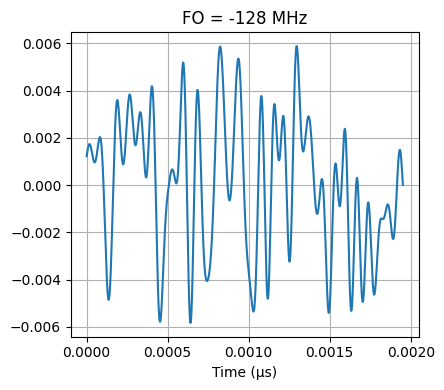

In [13]:
plt.figure(figsize=(12, 4))

for i, FO in enumerate(FO_values):
    paramLO.freqShift = FO
    paramLO.lw = 0

    sigRx = simulate_phase_noise()
    t = np.arange(len(sigRx)) / Fs

    plt.subplot(1, 3, i+1)
    plt.plot(t[:1000]*1e6, sigRx.real[:1000])

    plt.title(f"FO = {FO/1e6:.0f} MHz")
    plt.xlabel("Time (µs)")
    plt.grid()

plt.tight_layout()

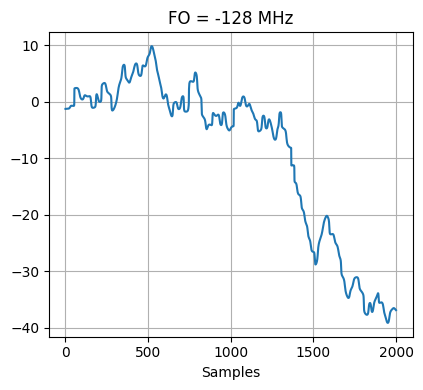

In [14]:
plt.figure(figsize=(12, 4))

for i, FO in enumerate(FO_values):
    paramLO.freqShift = FO
    paramLO.lw = 0

    sigRx = simulate_phase_noise()

    phase = np.unwrap(np.angle(sigRx))

    plt.subplot(1, 3, i+1)
    plt.plot(phase[:2000])

    plt.title(f"FO = {FO/1e6:.0f} MHz")
    plt.xlabel("Samples")
    plt.grid()

plt.tight_layout()

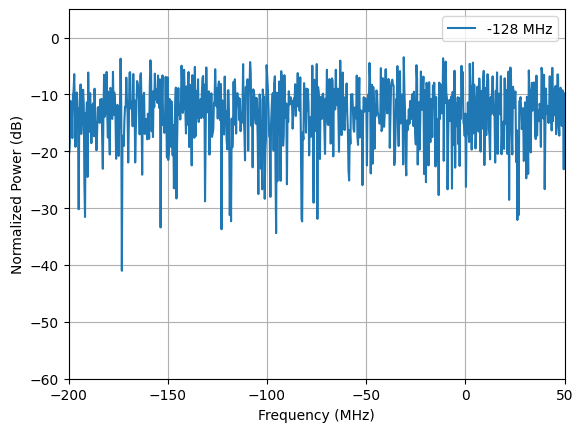

In [15]:
plt.figure()

for FO in FO_values:
    paramLO.freqShift = FO
    paramLO.lw = 0

    sigRx = simulate_phase_noise()

    S = np.fft.fftshift(np.fft.fft(sigRx))
    f = np.fft.fftshift(np.fft.fftfreq(len(S), d=1/Fs))

    power = 20*np.log10(np.abs(S))
    power -= np.max(power)

    plt.plot(f/1e6, power, label=f"{FO/1e6:.0f} MHz")

plt.xlim(-200, 50)
plt.ylim(-60, 5)
plt.xlabel("Frequency (MHz)")
plt.ylabel("Normalized Power (dB)")
plt.legend()
plt.grid()